In [252]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [253]:
df = pd.read_csv("german_credit_data.csv")
df.sample(5)

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
321,321,32,male,2,own,little,little,1938,24,radio/TV,bad
830,830,44,male,2,own,quite rich,NaN,2375,24,business,good
109,109,35,male,2,own,quite rich,moderate,1410,14,business,good
653,653,42,male,3,own,moderate,moderate,8086,36,car,bad
4,4,53,male,2,free,little,little,4870,24,car,bad


In [254]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [255]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


In [256]:
df.shape

(1000, 10)

In [257]:
df.isnull().sum().sort_values(ascending=False)

Checking account    394
Saving accounts     183
Age                   0
Sex                   0
Job                   0
Housing               0
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [258]:
df.describe(include='all').round()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
count,1000.0,1000,1000.0,1000,817,606,1000.0,1000.0,1000,1000
unique,NaN,2,NaN,3,4,3,NaN,NaN,8,2
top,NaN,male,NaN,own,little,little,NaN,NaN,car,good
freq,NaN,690,NaN,713,603,274,NaN,NaN,337,700
mean,36.0,NaN,2.0,NaN,NaN,NaN,3271.0,21.0,NaN,NaN
std,11.0,NaN,1.0,NaN,NaN,NaN,2823.0,12.0,NaN,NaN
min,19.0,NaN,0.0,NaN,NaN,NaN,250.0,4.0,NaN,NaN
25%,27.0,NaN,2.0,NaN,NaN,NaN,1366.0,12.0,NaN,NaN
50%,33.0,NaN,2.0,NaN,NaN,NaN,2320.0,18.0,NaN,NaN
75%,42.0,NaN,2.0,NaN,NaN,NaN,3972.0,24.0,NaN,NaN


In [259]:
df.columns = df.columns.str.replace(' ','_').str.lower()

In [260]:
df['job'].unique()

array([2, 1, 3, 0], dtype=int64)

In [261]:
df.isnull().sum().sort_values(ascending=False)

checking_account    394
saving_accounts     183
age                   0
sex                   0
job                   0
housing               0
credit_amount         0
duration              0
purpose               0
risk                  0
dtype: int64

In [262]:
df[df.isnull().any(axis=1)]

,age,sex,job,housing,saving_accounts,checking_account,credit_amount,duration,purpose,risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
2,49,male,1,own,little,NaN,2096,12,education,good
5,35,male,1,free,NaN,NaN,9055,36,education,good
6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment,good
8,61,male,1,own,rich,NaN,3059,12,radio/TV,good
...,...,...,...,...,...,...,...,...,...,...
991,34,male,1,own,moderate,NaN,1569,15,radio/TV,good
992,23,male,1,rent,NaN,little,1936,18,radio/TV,good
994,50,male,2,own,NaN,NaN,2390,12,car,good
995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good


In [263]:
df[df.isnull().any(axis=1)].shape

(478, 10)

In [264]:
df.duplicated().sum()

0

In [265]:
df.dropna(inplace=True)

In [266]:
df.reset_index(inplace=True)

In [267]:
df.isnull().sum()

index               0
age                 0
sex                 0
job                 0
housing             0
saving_accounts     0
checking_account    0
credit_amount       0
duration            0
purpose             0
risk                0
dtype: int64

In [268]:
df.head(2)

,index,age,sex,job,housing,saving_accounts,checking_account,credit_amount,duration,purpose,risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good


In [269]:
df.drop(columns=['index'],inplace=True)

In [270]:
num_for_hist = df.select_dtypes(include=['int64'])
num_for_hist.head()

,age,job,credit_amount,duration
0,22,2,5951,48
1,45,2,7882,42
2,53,2,4870,24
3,35,3,6948,36
4,28,3,5234,30


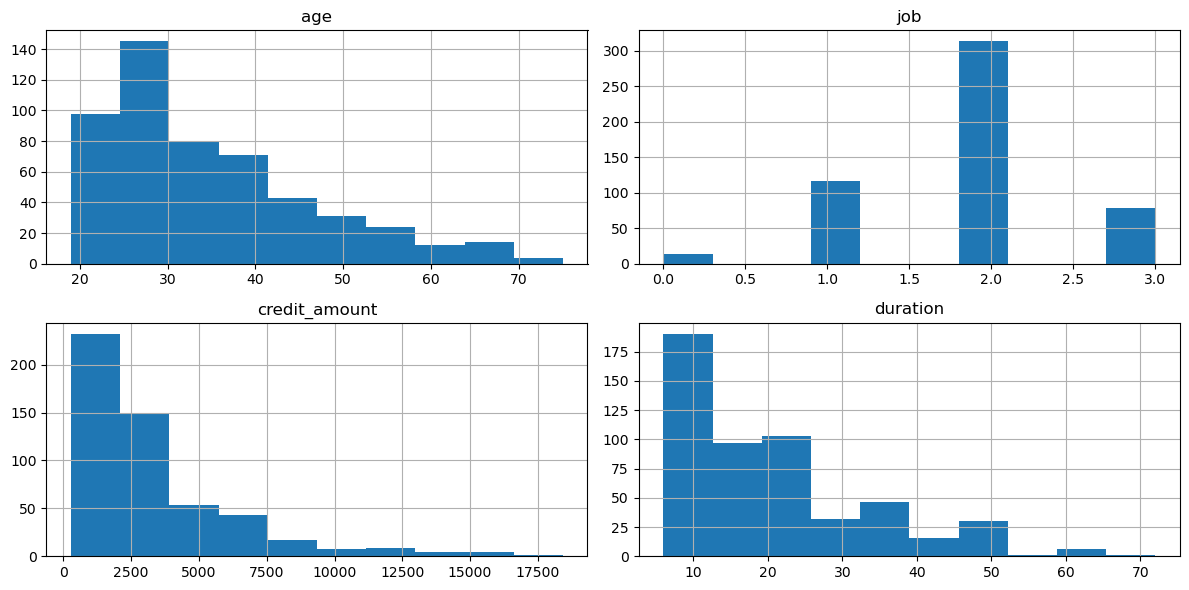

In [271]:
df.hist(figsize=(12,6))
plt.tight_layout()
plt.show()

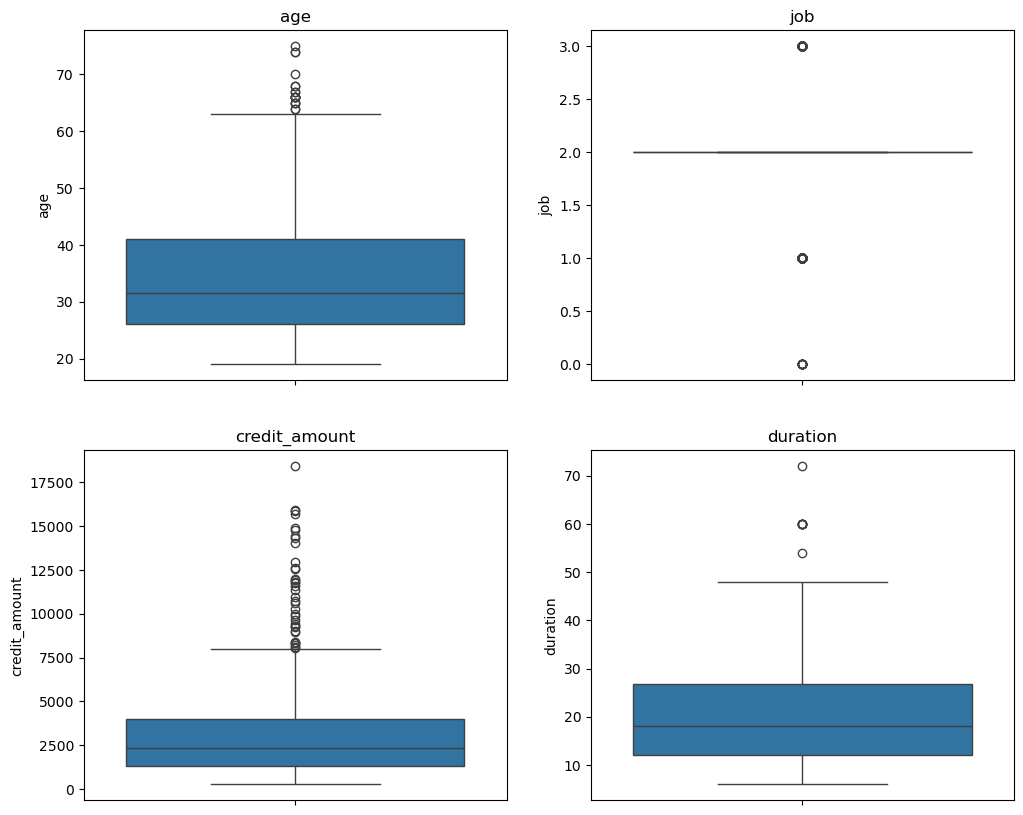

In [272]:
plt.figure(figsize=(12,10))
for i, col in enumerate(num_for_hist):
    plt.subplot(2, 2, i+1)   
    sns.boxplot(y=df[col])
    plt.title(col)

plt.show()

In [273]:
object1 = df.select_dtypes(include=['object'])
object1.head()

,sex,housing,saving_accounts,checking_account,purpose,risk
0,female,own,little,moderate,radio/TV,bad
1,male,free,little,little,furniture/equipment,good
2,male,free,little,little,car,bad
3,male,rent,little,moderate,car,good
4,male,own,little,moderate,car,bad


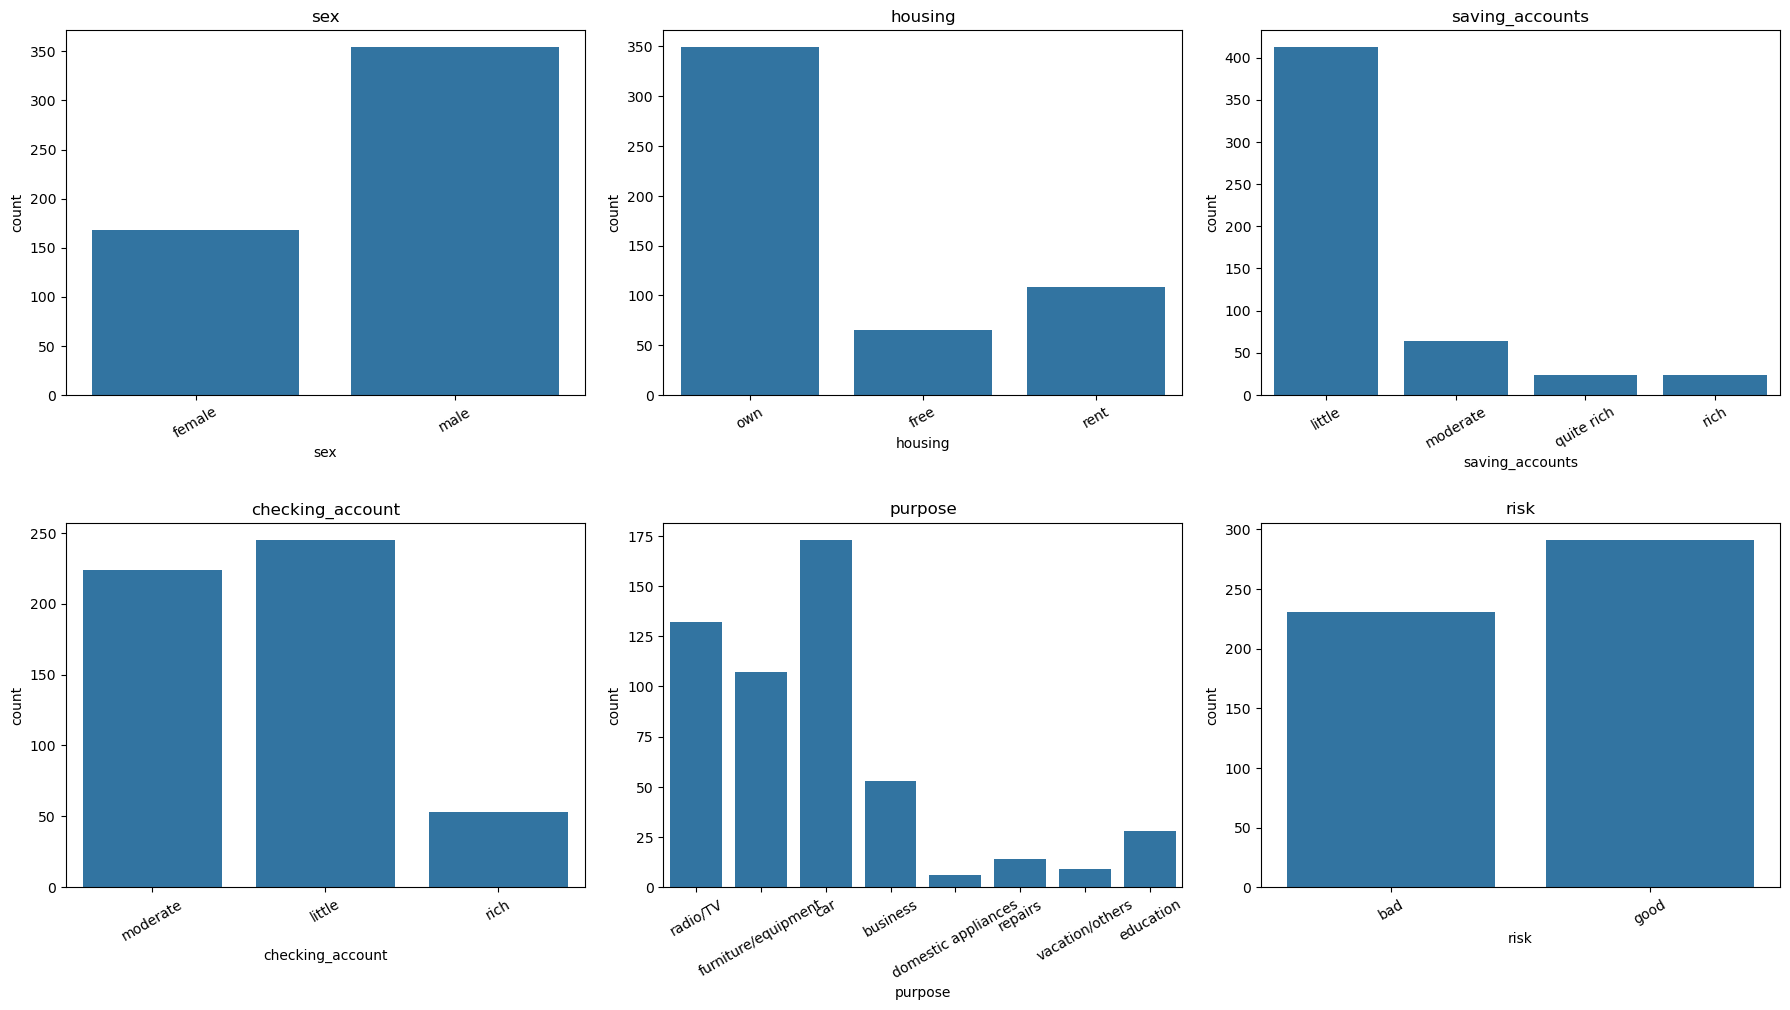

In [274]:
plt.figure(figsize=(18,14))

for idx, col in enumerate(object1):
    plt.subplot(3, 3, idx+1)
    sns.countplot(x=df[col])
    plt.xticks(rotation=30)
    plt.title(col)

plt.tight_layout()
plt.show()

In [275]:
num_for_hist.corr()

,age,job,credit_amount,duration
age,1.000000,0.039771,0.082014,0.001549
job,0.039771,1.000000,0.334721,0.200794
credit_amount,0.082014,0.334721,1.000000,0.613298
duration,0.001549,0.200794,0.613298,1.000000


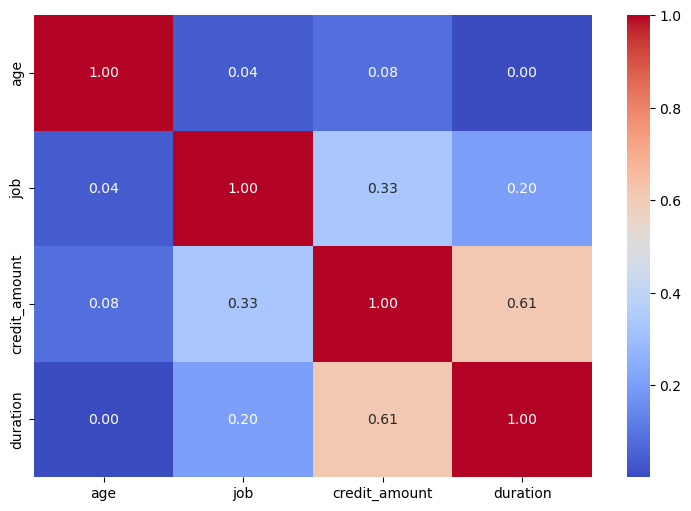

In [276]:
plt.figure(figsize=(9,6))
sns.heatmap(data = num_for_hist.corr() , fmt='.2f',annot=True ,cmap='coolwarm' )
plt.show()

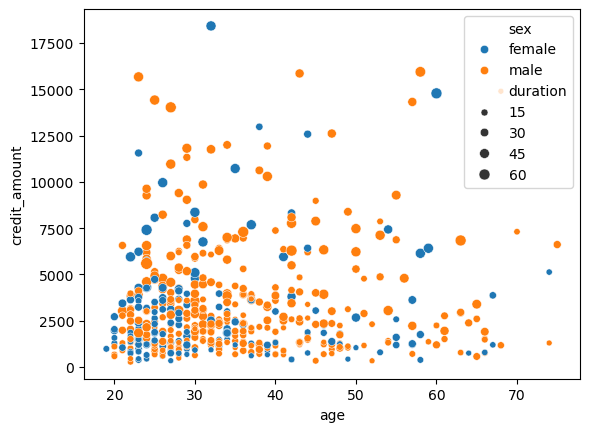

In [278]:
sns.scatterplot(x=df['age'],y=df['credit_amount'],hue=df['sex'],size=df['duration'])
plt.show()

In [279]:
(df['risk'].value_counts(normalize=True)*100).round(2)

risk
good    55.75
bad     44.25
Name: proportion, dtype: float64

In [281]:
df.groupby('risk')[['age','duration','credit_amount','duration']].mean().round()

,age,duration,credit_amount,duration
risk,,,,
bad,34.0,25.0,3881.0,25.0
good,35.0,18.0,2801.0,18.0


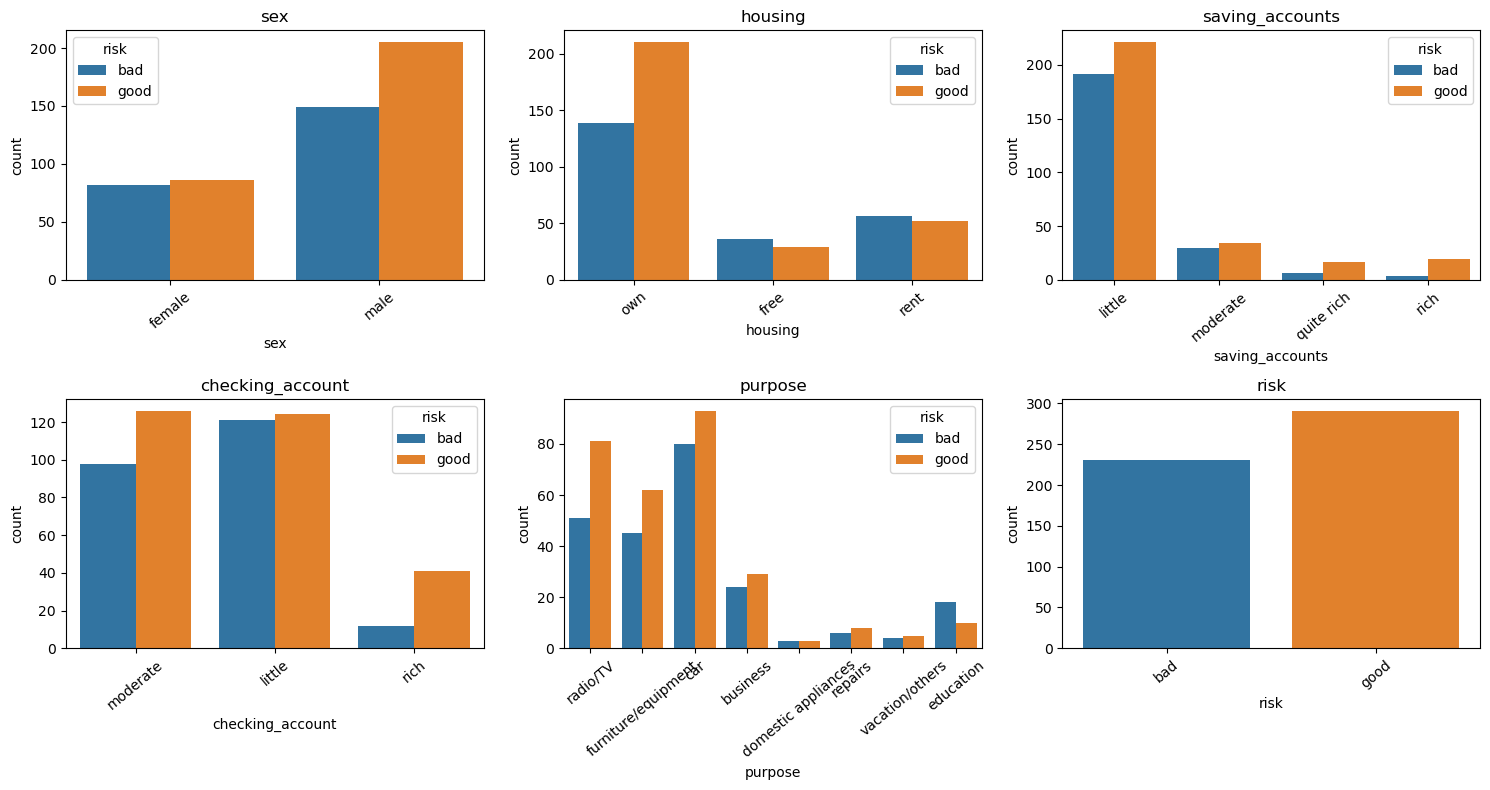

In [282]:
plt.figure(figsize=(15,8))
for idx, col in enumerate(object1):
    plt.subplot(2, 3, idx+1)
    sns.countplot(x=df[col], hue=df['risk'])
    plt.xticks(rotation=40)
    plt.title(col)
plt.tight_layout()
plt.show()

In [286]:
features = ['age','sex','job','housing','saving_accounts','checking_account','credit_amount','duration']
target = ['risk']

In [287]:
df_model = df[features+target].copy()

In [298]:
df_model.head()

,age,sex,job,housing,saving_accounts,checking_account,credit_amount,duration,risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [300]:
X = df_model[['age','sex','job','housing','saving_accounts','checking_account','credit_amount','duration']]
y = df_model['risk']

In [314]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

In [315]:
transformer = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(drop='first', sparse_output=False),
         ['sex','housing','saving_accounts','checking_account'])
    ],
    remainder='passthrough'
)

In [323]:
pipeline = Pipeline([
    ('transform', transformer),
    ('model', RandomForestClassifier())])

In [324]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [325]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.6095238095238096

In [326]:
import joblib

joblib.dump(pipeline, "credit_risk_model.pkl")

['credit_risk_model.pkl']

NameError: name 'app' is not defined